[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/05-xai-explainable-ai.ipynb)

# Explainable AI (XAI) in Medicine

**ELMED219 / BMED365 - Lab 3**


Last updated:<br>
2026-01-03, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Explain why explainability is important in medical AI
- Describe different XAI methods (SHAP, LIME, attention)
- Evaluate strengths and weaknesses of different explanation methods
- Discuss clinical requirements for AI interpretability

## Contents

1. [Why Explainable AI?](#1-why-explainable-ai)
2. [Types of Explainability](#2-types-of-explainability)
3. [SHAP - SHapley Additive exPlanations](#3-shap)
4. [LIME - Local Interpretable Model-agnostic Explanations](#4-lime)
5. [Attention-based Explanations](#5-attention-based-explanations)
6. [Clinical Requirements and Challenges](#6-clinical-requirements-and-challenges)

---

## 1. Why Explainable AI?

In healthcare, it's not enough that AI gives the right answer - we must also understand **why**.

### Reasons Why XAI is Critical in Medicine

| Reason | Explanation |
|-------|------------|
| **Trust** | Doctors must trust AI recommendations before acting |
| **Accountability** | When errors occur, we must understand what went wrong |
| **Regulation** | EU AI Act requires explainability for high-risk AI |
| **Learning** | Explanations can reveal new medical knowledge |
| **Debugging** | Identify bias or errors in the model |

### The Black Box

Complex models like deep neural networks and LLMs are often called "black boxes" because:

```
Input (Patient Data)  →  [???]  →  Output (Diagnosis/Risk)
         ↓                              ↓
    We understand              We see the answer
    what goes in              but not WHY
```

XAI methods try to open this box.

In [1]:
# Environment Setup
import sys
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Set matplotlib to use a fixed random state for reproducibility
plt.rcParams['figure.dpi'] = 100

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running in local environment")

print("Ready for XAI demonstrations!")
print(f"Random seed set to {RANDOM_SEED} for reproducibility")

Running in local environment
Ready for XAI demonstrations!
Random seed set to 42 for reproducibility


---

## 2. Types of Explainability

### Global vs. Local Explainability

| Type | Question | Example |
|------|----------|----------|
| **Global** | How does the model work in general? | "Blood pressure is the most important factor for heart disease" |
| **Local** | Why this answer for this patient? | "This patient got high risk due to smoking + high cholesterol" |

### Ante-hoc vs. Post-hoc

| Type | When | Example |
|------|-----|----------|
| **Ante-hoc** | Built into the model | Decision trees, linear regression |
| **Post-hoc** | Analyzes finished model | SHAP, LIME, GradCAM |

In [2]:
# Example: Simple interpretable model vs. complex model

# Interpretable model: Linear risk score
def interpretable_risk_score(age, blood_pressure, cholesterol, smoker):
    """
    Simple, interpretable risk model.
    Each factor contributes with a known weight.
    """
    score = 0
    
    # Age risk
    if age > 60:
        score += 2
    elif age > 40:
        score += 1
    
    # Blood pressure
    if blood_pressure > 140:
        score += 2
    elif blood_pressure > 120:
        score += 1
    
    # Cholesterol
    if cholesterol > 6.5:
        score += 2
    elif cholesterol > 5.0:
        score += 1
    
    # Smoking
    if smoker:
        score += 3
    
    return score

# Test on a patient
patient = {
    'age': 65,
    'blood_pressure': 145,
    'cholesterol': 6.8,
    'smoker': True
}

score = interpretable_risk_score(**patient)

print("INTERPRETABLE MODEL - Heart Disease Risk")
print("=" * 50)
print(f"Patient: {patient}")
print(f"Risk Score: {score}/9")
print()
print("Explanation (easy to understand):")
print(f"  - Age 65 years: +2 points (over 60)")
print(f"  - BP 145: +2 points (over 140)")
print(f"  - Cholesterol 6.8: +2 points (over 6.5)")
print(f"  - Smoker: +3 points")
print(f"  = Total {score} points")

INTERPRETABLE MODEL - Heart Disease Risk
Patient: {'age': 65, 'blood_pressure': 145, 'cholesterol': 6.8, 'smoker': True}
Risk Score: 9/9

Explanation (easy to understand):
  - Age 65 years: +2 points (over 60)
  - BP 145: +2 points (over 140)
  - Cholesterol 6.8: +2 points (over 6.5)
  - Smoker: +3 points
  = Total 9 points


---

## 3. SHAP - SHapley Additive exPlanations

SHAP is based on game theory (Shapley values) and explains predictions by calculating each feature's contribution.

### How SHAP Works

1. For a given prediction, SHAP calculates how much **each feature** contributes to moving the prediction from the average
2. Positive SHAP values increase the prediction, negative values decrease it
3. Sum of all SHAP values = prediction - average prediction

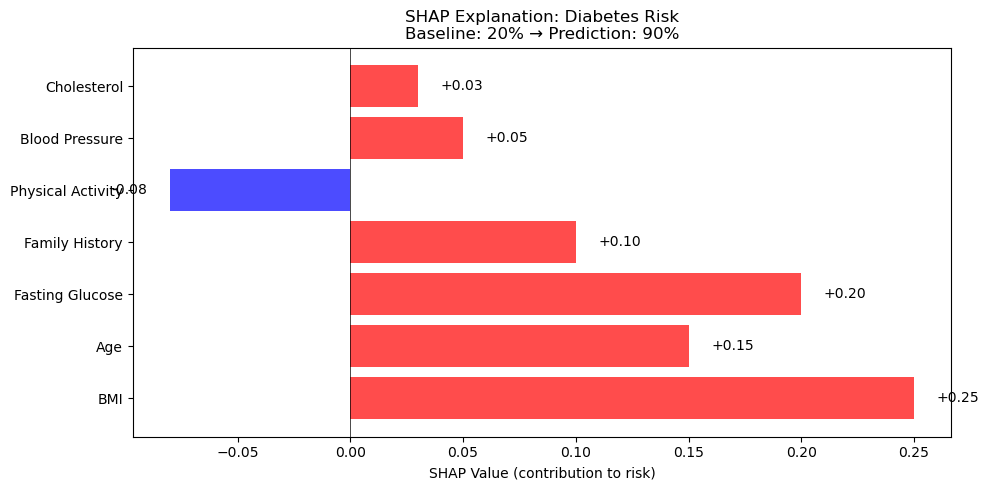


Interpretation for clinician:
--------------------------------------------------
This patient has 90% risk of diabetes (average: 20%)

Main causes of increased risk:
  - BMI: +0.25
  - Fasting Glucose: +0.20
  - Age: +0.15


In [3]:
# Simulated SHAP explanation for a diabetes risk model

def simulate_shap_explanation():
    """
    Simulates a SHAP explanation for demonstration.
    In practice, we would use the shap library on a real model.
    """
    # Patient with high diabetes risk
    features = ['BMI', 'Age', 'Fasting Glucose', 'Family History', 
                'Physical Activity', 'Blood Pressure', 'Cholesterol']
    
    # SHAP values (simulated): positive = increases risk, negative = decreases
    shap_values = [0.25, 0.15, 0.20, 0.10, -0.08, 0.05, 0.03]
    
    # Baseline and prediction
    baseline = 0.20  # Average risk in population
    prediction = baseline + sum(shap_values)  # 0.90
    
    return features, shap_values, baseline, prediction

features, shap_values, baseline, prediction = simulate_shap_explanation()

# Visualize SHAP values
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if v > 0 else 'blue' for v in shap_values]
y_pos = range(len(features))

ax.barh(y_pos, shap_values, color=colors, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('SHAP Value (contribution to risk)')
ax.set_title(f'SHAP Explanation: Diabetes Risk\nBaseline: {baseline:.0%} → Prediction: {prediction:.0%}')
ax.axvline(x=0, color='black', linewidth=0.5)

# Add values on bars
for i, (feature, value) in enumerate(zip(features, shap_values)):
    ax.text(value + 0.01 if value > 0 else value - 0.01, i, 
            f'{value:+.2f}', va='center', 
            ha='left' if value > 0 else 'right')

plt.tight_layout()
plt.show()

print("\nInterpretation for clinician:")
print("-" * 50)
print(f"This patient has {prediction:.0%} risk of diabetes (average: {baseline:.0%})")
print("\nMain causes of increased risk:")
for f, v in sorted(zip(features, shap_values), key=lambda x: x[1], reverse=True)[:3]:
    print(f"  - {f}: {v:+.2f}")

### Advantages and Disadvantages of SHAP

| Advantages | Disadvantages |
|----------|----------|
| Theoretical foundation (Shapley) | Can be computationally demanding |
| Consistent and fair | Explanations can be difficult to interpret |
| Works for all model types | Requires access to training data |

---

## 4. LIME - Local Interpretable Model-agnostic Explanations

LIME explains individual predictions by building a simple, interpretable model locally around the prediction.

### How LIME Works

1. Generate perturbed versions of input (with small changes)
2. Get predictions for all perturbed versions
3. Train a simple model (e.g., linear) on these
4. Use the simple model to explain

LIME Explanation for Text Classification
Text: 'The patient has chest pain and shortness of breath during exertion'
Classification: Heart Disease (probability: 85%)

Words contributing to classification:
  chest           ███████ (+0.35)
  pain            ███████ (+0.35)
  shortness       █████ (+0.25)
  breath          █████ (+0.25)
  exertion        ███ (+0.15)


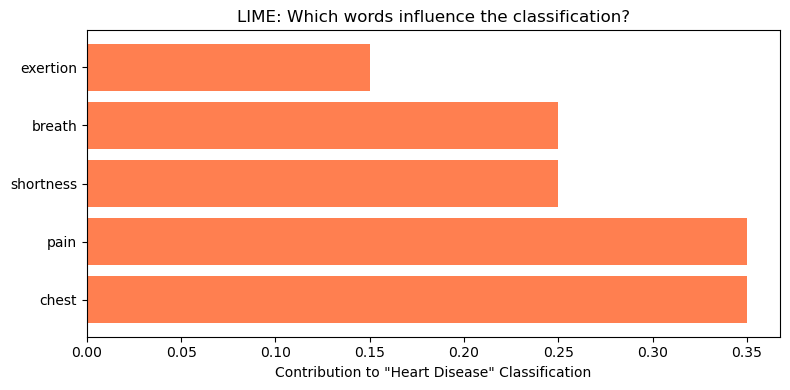

In [4]:
# Simulated LIME explanation for text classification

def simulate_lime_text_explanation():
    """
    Simulates a LIME explanation for a medical text classification.
    """
    text = "The patient has chest pain and shortness of breath during exertion"
    
    # Simulated word contributions to the "Heart Disease" classification
    word_contributions = {
        'chest': 0.35,
        'pain': 0.35,
        'shortness': 0.25,
        'breath': 0.25,
        'exertion': 0.15,
        'The': 0.0,
        'patient': 0.0,
        'has': 0.0,
        'and': 0.0,
        'of': 0.0,
        'during': 0.0
    }
    
    return text, word_contributions

text, word_contributions = simulate_lime_text_explanation()

print("LIME Explanation for Text Classification")
print("=" * 50)
print(f"Text: '{text}'")
print(f"Classification: Heart Disease (probability: 85%)")
print()
print("Words contributing to classification:")
for word, contribution in sorted(word_contributions.items(), key=lambda x: x[1], reverse=True):
    if contribution > 0:
        bar = '█' * int(contribution * 20)
        print(f"  {word:15s} {bar} ({contribution:+.2f})")

# Visualize
important_words = [(k, v) for k, v in word_contributions.items() if v > 0]
words, values = zip(*important_words)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(words, values, color='coral')
ax.set_xlabel('Contribution to "Heart Disease" Classification')
ax.set_title('LIME: Which words influence the classification?')
plt.tight_layout()
plt.show()

---

## 5. Attention-based Explanations

For transformer models like LLMs, we can visualize **attention weights** to see what the model "focuses" on.

### Important Caveat

Attention is *not* the same as explanation! Research shows that:
- High attention does not necessarily mean causal influence
- The same prediction can have different attention patterns
- Attention can be misleading

However, it can still provide useful insights as a starting point for further analysis.

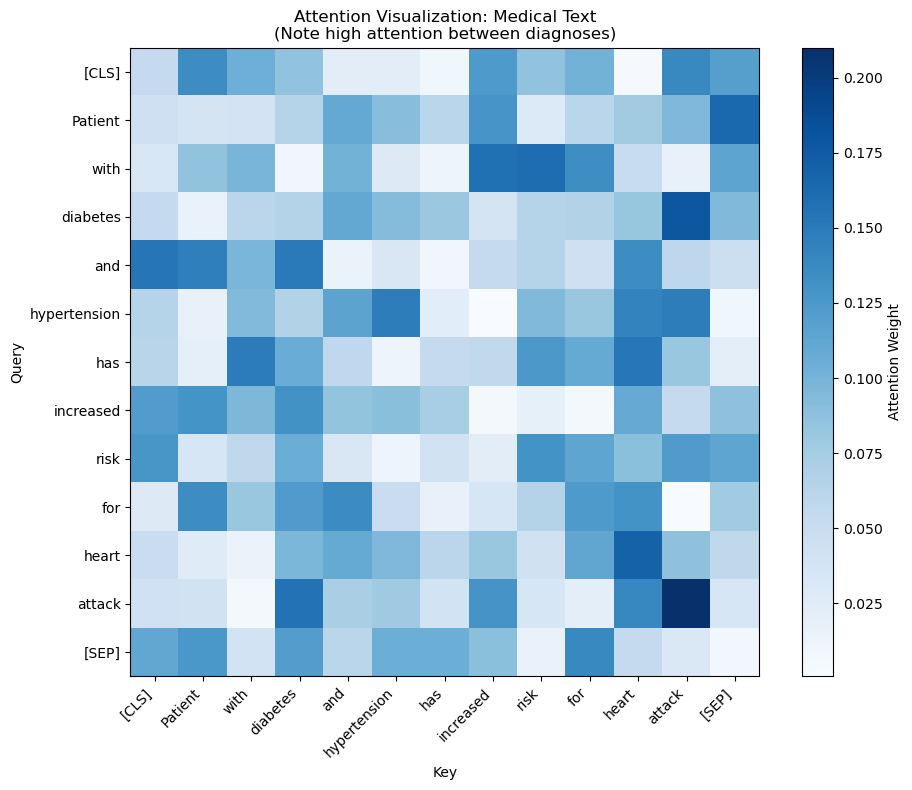

Observation:
The model shows high attention between 'diabetes', 'hypertension' and 'heart attack',
which indicates that it has learned the relationship between these diagnoses.


In [5]:
# Simulated attention visualization

import matplotlib.pyplot as plt
import numpy as np

def visualize_attention_medical():
    """Simulate attention for a medical sentence."""
    
    tokens = ['[CLS]', 'Patient', 'with', 'diabetes', 'and', 'hypertension', 
              'has', 'increased', 'risk', 'for', 'heart', 'attack', '[SEP]']
    
    # Simulated attention matrix (13x13)
    # Using same seed as global setup for reproducibility
    np.random.seed(42)
    attention = np.random.rand(len(tokens), len(tokens))
    
    # Make attention more realistic: diseases should have high attention to each other
    disease_idx = [3, 5, 10, 11]  # diabetes, hypertension, heart, attack
    for i in disease_idx:
        for j in disease_idx:
            attention[i, j] += 0.5
    
    # Normalize
    attention = attention / attention.sum(axis=1, keepdims=True)
    
    return tokens, attention

tokens, attention = visualize_attention_medical()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attention, cmap='Blues')

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)

ax.set_xlabel('Key')
ax.set_ylabel('Query')
ax.set_title('Attention Visualization: Medical Text\n(Note high attention between diagnoses)')

plt.colorbar(im, label='Attention Weight')
plt.tight_layout()
plt.show()

print("Observation:")
print("The model shows high attention between 'diabetes', 'hypertension' and 'heart attack',")
print("which indicates that it has learned the relationship between these diagnoses.")

---

## 6. Clinical Requirements and Challenges

### What Do Clinicians Need?

Research shows that doctors want explanations that are:

1. **Short and precise** - not long technical reports
2. **Clinically relevant** - related to known risk factors
3. **Actionable** - provide basis for making decisions
4. **Honest about uncertainty** - don't oversell the model's confidence

### EU AI Act and Explainability

Under the EU's AI regulation, medical AI is often classified as **high-risk**, which requires:

- Documentation of how the model works
- Possibility for human override
- Logging of decisions
- Explanations tailored to users

In [6]:
# Example: Clinician-friendly explanation

def generate_clinical_explanation(patient, risk, factors):
    """
    Generates a clinician-friendly explanation for a risk assessment.
    """
    explanation = f"""
╔══════════════════════════════════════════════════════════════╗
║  AI-SUPPORTED RISK ASSESSMENT                                ║
╚══════════════════════════════════════════════════════════════╝

PATIENT: {patient['id']}
ASSESSMENT: {risk['category']} ({risk['score']:.0%})

MAIN FACTORS (from AI analysis):
"""
    for i, (factor, contribution, direction) in enumerate(factors, 1):
        arrow = "↑" if direction == 'increases' else "↓"
        explanation += f"  {i}. {factor} {arrow} ({contribution})\n"
    
    explanation += f"""
UNCERTAINTY: The model is {risk['confidence']}% confident in this assessment.

⚠️  IMPORTANT: This is decision support, not a diagnosis.
    Clinical judgment is always required.
"""
    return explanation

# Test
patient = {'id': 'P-2024-001'}
risk = {'category': 'High Risk', 'score': 0.78, 'confidence': 85}
factors = [
    ('Age over 65 years', '+15%', 'increases'),
    ('Type 2 Diabetes', '+12%', 'increases'),
    ('Active smoker', '+18%', 'increases'),
    ('Regular exercise', '-8%', 'decreases')
]

print(generate_clinical_explanation(patient, risk, factors))


╔══════════════════════════════════════════════════════════════╗
║  AI-SUPPORTED RISK ASSESSMENT                                ║
╚══════════════════════════════════════════════════════════════╝

PATIENT: P-2024-001
ASSESSMENT: High Risk (78%)

MAIN FACTORS (from AI analysis):
  1. Age over 65 years ↑ (+15%)
  2. Type 2 Diabetes ↑ (+12%)
  3. Active smoker ↑ (+18%)
  4. Regular exercise ↓ (-8%)

UNCERTAINTY: The model is 85% confident in this assessment.

⚠️  IMPORTANT: This is decision support, not a diagnosis.
    Clinical judgment is always required.



---

## Summary

### Key Points

1. **Explainability is critical** in medical AI for trust, accountability, and regulation
2. **SHAP** provides theoretically grounded explanations based on game theory
3. **LIME** builds local interpretable models around predictions
4. **Attention** can provide insights, but is not the same as causal explanation
5. **Clinical explanations** must be short, relevant, and actionable

### Reflection Questions

1. When would you prefer SHAP over LIME, and vice versa?
2. How would you explain an AI risk assessment to a patient vs. a doctor?
3. What ethical challenges do you see with using AI without good explainability?

---

*Next notebook: [06 - AI Ethics in Medicine](06-ai-ethics-medicine.ipynb)*